# Retriever Evaluation

Before layering on advanced retrieval techniques (hybrid search, reranking, query expansion, MMR, etc.), we need  know of how well the current cosine-similarity retriever performs.

This notebook builds a small evaluation harness for the RAG pipeline created in `document.ipynb`. It:

1. Reconnects to the existing (already-persisted) ChromaDB vector store no need to re-embed anything.
2. Builds a **golden evaluation set** of `(query, relevant_doc_ids)` pairs from the source corpus.
3. Runs retrieval for every query and computes standard IR metrics: **Hit Rate**, **MRR**, **Precision@k**, **Recall@k**, and **NDCG@k**.
4. Visualizes results and inspects the worst-performing queries.
5. Measures retrieval latency.

In [1]:
import os
import json
import time
import random
from pathlib import Path
from typing import List, Dict, Any

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import chromadb
from sentence_transformers import SentenceTransformer

import warnings
warnings.filterwarnings("ignore")

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)


d:\RAG_Project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### 1. Reconnect to the Existing Vector Store

The ingestion notebook persisted a ChromaDB collection to disk (`../data/vector_store`, collection name `json_qa_documents`). We reconnect to it directly instead of re-running ingestion or re-embedding the corpus evaluation should test the *retriever as it already exists*.

We only need two things: the embedding model (to embed queries) and a handle to the persisted collection (to search).

In [6]:
EMBEDDING_MODEL_NAME = "BAAI/bge-small-en-v1.5"  
PERSIST_DIRECTORY = "../data/vector_store"
COLLECTION_NAME = "json_qa_documents"

print(f"Loading embedding model: {EMBEDDING_MODEL_NAME} ...")
embedding_model = SentenceTransformer(EMBEDDING_MODEL_NAME)
print("Model loaded.")

client = chromadb.PersistentClient(path=PERSIST_DIRECTORY)
collection = client.get_collection(name=COLLECTION_NAME)

print(f"Connected to collection '{COLLECTION_NAME}'")
print(f"Documents in collection: {collection.count()}")


Loading embedding model: BAAI/bge-small-en-v1.5 ...


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 1581.67it/s]


Model loaded.
Connected to collection 'json_qa_documents'
Documents in collection: 2964


### 2. Building a Golden Evaluation Set

The JSON corpus (`bliss_corpus.json`) is a set of self-contained Question/Answer pairs, each already stored in the vector store with its own `doc_id`. This gives us a golden set almost for free:

- **query** → the `question` field of a record
- **relevant_doc_ids** → the `doc_id` of that same record

In [7]:
CORPUS_PATH = Path("../data/json_files/bliss_corpus.json")

with open(CORPUS_PATH, "r", encoding="utf-8") as f:
    corpus_records = json.load(f)

print(f"Loaded {len(corpus_records)} records from corpus")

eval_set = []
for record in corpus_records:
    doc_id = record.get("doc_id")
    question = record.get("question")
    if doc_id and question:
        meta = record.get("metadata", {})
        eval_set.append({
            "query": question,
            "relevant_doc_ids": [doc_id],
            "topic_group": meta.get("topic_group", "unknown"),
            "flags": meta.get("flags", []) or [],
        })

print(f"Built {len(eval_set)} query/ground-truth pairs")

# Optional: evaluate on a random sample instead of the full set, for speed while iterating.
# Set SAMPLE_SIZE = None to evaluate on everything.
SAMPLE_SIZE = 100
if SAMPLE_SIZE and SAMPLE_SIZE < len(eval_set):
    eval_set = random.sample(eval_set, SAMPLE_SIZE)
    print(f"Sampled down to {len(eval_set)} queries for this run")

pd.DataFrame(eval_set).head()


Loaded 2964 records from corpus
Built 2964 query/ground-truth pairs
Sampled down to 100 queries for this run


,query,relevant_doc_ids,topic_group,flags
0,Does this go against any ethical codes? Are th...,[cc_q401_a001],relationships_family,[]
1,"I have these dreams of men, and they always se...",[cc_q187_a003],anxiety_stress,[hotline_reference]
2,I crossdress and like to be feminine but I am ...,[cc_q493_a001],relationships_family,[long_personal_post_question]
3,I am a teenage girl. I've been seeing the same...,[cc_q225_a001],anxiety_stress,[long_personal_post_question]
4,"As a child, my parents injured my brother, so ...",[cc_q432_a002],trauma_ptsd,[]


### 3. Retrieval Function for Evaluation

The pipeline's `RAGRetriever.retrieve()` drops any result below `score_threshold` (default `0.3`). That's the right behavior for production, where you don't want to hand a downstream LLM garbage context but it's the *wrong* behavior for evaluation, because it silently removes candidates before we get to measure how well they were **ranked**.

For evaluation we want the raw ranked list of `top_k` results, with no thresholding, so metrics like MRR and NDCG reflect ranking quality rather than an arbitrary cutoff.

In [8]:
def retrieve_for_eval(query: str, top_k: int) -> List[str]:
    """
    Retrieve the top_k document ids for a query, ranked best-first,
    with no similarity-score filtering.
    """
    query_embedding = embedding_model.encode([query])[0]
    results = collection.query(
        query_embeddings=[query_embedding.tolist()],
        n_results=top_k,
    )
    if results["ids"] and results["ids"][0]:
        return results["ids"][0]
    return []


# Quick sanity check
sample_query = eval_set[0]["query"]
print(f"Query: {sample_query}")
print(f"Expected relevant doc_id(s): {eval_set[0]['relevant_doc_ids']}")
print(f"Retrieved (top 5): {retrieve_for_eval(sample_query, top_k=5)}")


Query: Does this go against any ethical codes? Are there legal ramifications?
Expected relevant doc_id(s): ['cc_q401_a001']
Retrieved (top 5): ['cc_q401_a001', 'cc_q396_a001', 'cc_q896_a003', 'cc_q396_a003', 'cc_q262_a002']


## 4. Retrieval Metrics

 5 standard metrics:

| Metric | Question it answers |
|---|---|
| **Hit Rate@k** | Did *any* relevant document appear in the top k results? (binary, per query) |
| **MRR** (Mean Reciprocal Rank) | How near the *top* was the first relevant result? (1 / rank of first hit) |
| **Precision@k** | Of the k results returned, what fraction were relevant? |
| **Recall@k** | Of all relevant documents that exist, what fraction did we find in the top k? |
| **NDCG@k** | Precision *and* ranking quality combined rewards relevant results appearing earlier, penalizes them appearing later |

Hit Rate and MRR are the most intuitive for a QA-style retriever like this one (usually there's one "right" chunk to find). Precision/Recall/NDCG matter more as `relevant_doc_ids` grows past one document per query.

In [9]:
def hit_rate_at_k(retrieved_ids: List[str], relevant_ids: List[str], k: int) -> int:
    """1 if at least one relevant doc is in the top k retrieved, else 0."""
    top_k = retrieved_ids[:k]
    return int(any(doc_id in relevant_ids for doc_id in top_k))


def reciprocal_rank(retrieved_ids: List[str], relevant_ids: List[str]) -> float:
    """1 / rank of the first relevant doc found (0 if none found)."""
    for rank, doc_id in enumerate(retrieved_ids, start=1):
        if doc_id in relevant_ids:
            return 1.0 / rank
    return 0.0


def precision_at_k(retrieved_ids: List[str], relevant_ids: List[str], k: int) -> float:
    top_k = retrieved_ids[:k]
    if not top_k:
        return 0.0
    num_relevant_in_top_k = sum(1 for doc_id in top_k if doc_id in relevant_ids)
    return num_relevant_in_top_k / len(top_k)


def recall_at_k(retrieved_ids: List[str], relevant_ids: List[str], k: int) -> float:
    if not relevant_ids:
        return 0.0
    top_k = retrieved_ids[:k]
    num_relevant_found = sum(1 for doc_id in top_k if doc_id in relevant_ids)
    return num_relevant_found / len(relevant_ids)


def ndcg_at_k(retrieved_ids: List[str], relevant_ids: List[str], k: int) -> float:
    """Binary-relevance NDCG@k."""
    top_k = retrieved_ids[:k]

    dcg = 0.0
    for i, doc_id in enumerate(top_k):
        relevance = 1.0 if doc_id in relevant_ids else 0.0
        dcg += relevance / np.log2(i + 2)  # i+2 because ranks start at 1, log2(1)=0

    num_relevant = min(len(relevant_ids), k)
    idcg = sum(1.0 / np.log2(i + 2) for i in range(num_relevant))

    return dcg / idcg if idcg > 0 else 0.0


### 5. Running the Evaluation

In [10]:
K_VALUES = [1, 3, 5, 10]
MAX_K = max(K_VALUES)

per_query_results = []

for item in eval_set:
    query = item["query"]
    relevant_ids = item["relevant_doc_ids"]

    retrieved_ids = retrieve_for_eval(query, top_k=MAX_K)

    row = {
        "query": query,
        "relevant_doc_ids": relevant_ids,
        "retrieved_doc_ids": retrieved_ids,
        "topic_group": item.get("topic_group", "unknown"),
        "flags": item.get("flags", []),
        "is_safety_sensitive": "safety_sensitive" in item.get("flags", []),
        "reciprocal_rank": reciprocal_rank(retrieved_ids, relevant_ids),
    }
    for k in K_VALUES:
        row[f"hit_rate@{k}"] = hit_rate_at_k(retrieved_ids, relevant_ids, k)
        row[f"precision@{k}"] = precision_at_k(retrieved_ids, relevant_ids, k)
        row[f"recall@{k}"] = recall_at_k(retrieved_ids, relevant_ids, k)
        row[f"ndcg@{k}"] = ndcg_at_k(retrieved_ids, relevant_ids, k)

    per_query_results.append(row)

results_df = pd.DataFrame(per_query_results)
print(f"Evaluated {len(results_df)} queries")
results_df.head()


Evaluated 100 queries


,query,relevant_doc_ids,retrieved_doc_ids,topic_group,flags,is_safety_sensitive,reciprocal_rank,hit_rate@1,precision@1,recall@1,...,recall@3,ndcg@3,hit_rate@5,precision@5,recall@5,ndcg@5,hit_rate@10,precision@10,recall@10,ndcg@10
0,Does this go against any ethical codes? Are th...,[cc_q401_a001],"[cc_q401_a001, cc_q396_a001, cc_q896_a003, cc_...",relationships_family,[],False,1.000000,1,1.0,1.0,...,1.0,1.00000,1,0.2,1.0,1.00000,1,0.1,1.0,1.000000
1,"I have these dreams of men, and they always se...",[cc_q187_a003],"[cc_q187_a002, cc_q187_a003, cc_q187_a001, cc_...",anxiety_stress,[hotline_reference],False,0.500000,0,0.0,0.0,...,1.0,0.63093,1,0.2,1.0,0.63093,1,0.1,1.0,0.630930
2,I crossdress and like to be feminine but I am ...,[cc_q493_a001],"[cc_q493_a007, cc_q493_a004, cc_q493_a006, cc_...",relationships_family,[long_personal_post_question],False,0.166667,0,0.0,0.0,...,0.0,0.00000,0,0.0,0.0,0.00000,1,0.1,1.0,0.356207
3,I am a teenage girl. I've been seeing the same...,[cc_q225_a001],"[cc_q225_a001, cc_q185_a001, cc_q484_a003, cc_...",anxiety_stress,[long_personal_post_question],False,1.000000,1,1.0,1.0,...,1.0,1.00000,1,0.2,1.0,1.00000,1,0.1,1.0,1.000000
4,"As a child, my parents injured my brother, so ...",[cc_q432_a002],"[cc_q439_a001, cc_q432_a001, cc_q432_a002, cc_...",trauma_ptsd,[],False,0.333333,0,0.0,0.0,...,1.0,0.50000,1,0.2,1.0,0.50000,1,0.1,1.0,0.500000


In [11]:
metric_cols = [c for c in results_df.columns if "@" in c or c == "reciprocal_rank"]
summary = results_df[metric_cols].mean().rename("score").to_frame()
summary.loc["MRR"] = results_df["reciprocal_rank"].mean()
summary = summary.drop(index="reciprocal_rank")
summary = summary.round(4)
summary


,score
hit_rate@1,0.3600
precision@1,0.3600
recall@1,0.3600
ndcg@1,0.3600
hit_rate@3,0.6500
precision@3,0.2167
recall@3,0.6500
ndcg@3,0.5259
hit_rate@5,0.6800
precision@5,0.1360


## 6. Visualizing Results

Two views are useful here:

- A **bar chart at a single k** (e.g. k=5) to see all four metrics side by side.
- A **line chart across k** to see how quickly quality improves as we allow more results — a retriever with a low Hit Rate@1 but high Hit Rate@10 is finding the right document, just not ranking it near the top (a good candidate for a reranker later).

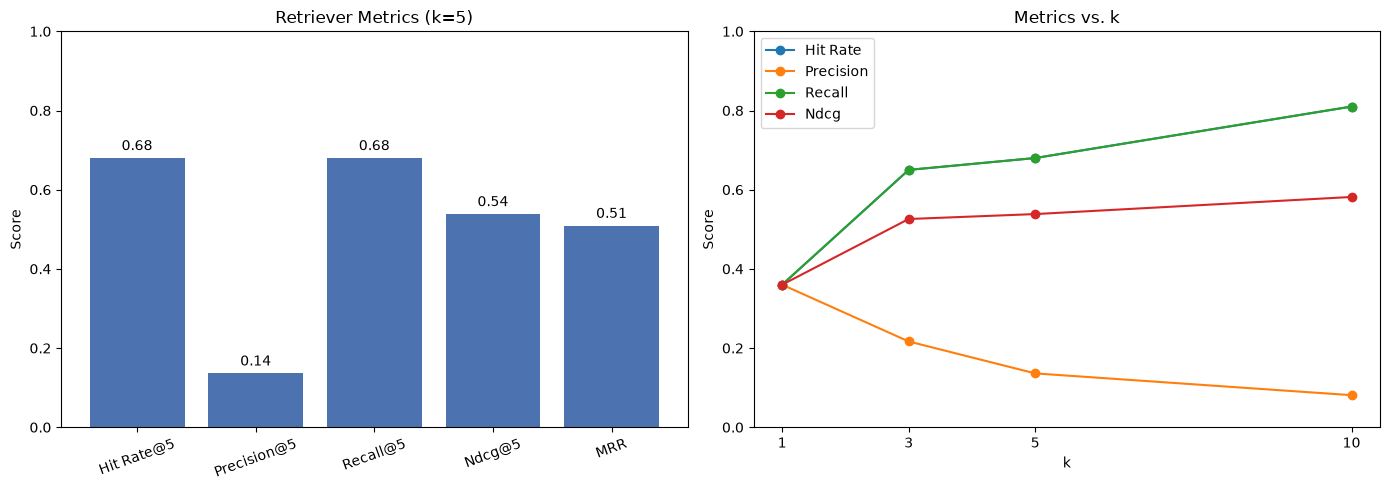

In [12]:
EVAL_K = 5  # pick one k to summarize in the bar chart

metrics_at_k = ["hit_rate", "precision", "recall", "ndcg"]
bar_values = [results_df[f"{m}@{EVAL_K}"].mean() for m in metrics_at_k]
bar_values.append(results_df["reciprocal_rank"].mean())
bar_labels = [f"{m.replace('_', ' ').title()}@{EVAL_K}" for m in metrics_at_k] + ["MRR"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(bar_labels, bar_values, color="#4C72B0")
axes[0].set_ylim(0, 1)
axes[0].set_title(f"Retriever Metrics (k={EVAL_K})")
axes[0].set_ylabel("Score")
axes[0].tick_params(axis="x", rotation=20)
for i, v in enumerate(bar_values):
    axes[0].text(i, v + 0.02, f"{v:.2f}", ha="center")

for metric in metrics_at_k:
    values = [results_df[f"{metric}@{k}"].mean() for k in K_VALUES]
    axes[1].plot(K_VALUES, values, marker="o", label=metric.replace("_", " ").title())
axes[1].set_xlabel("k")
axes[1].set_ylabel("Score")
axes[1].set_ylim(0, 1)
axes[1].set_title("Metrics vs. k")
axes[1].legend()
axes[1].set_xticks(K_VALUES)

plt.tight_layout()
plt.show()


## 7. Error Analysis — Where Retrieval Fails

Aggregate metrics tell you *how well* the retriever does on average, but not *why* it fails. The most actionable step in retriever evaluation is reading the actual misses: queries where the correct document never showed up in the top k at all.

In [13]:
MISS_K = 5

misses = results_df[results_df[f"hit_rate@{MISS_K}"] == 0].copy()
print(f"{len(misses)} / {len(results_df)} queries had no relevant document in the top {MISS_K} results")

for _, row in misses.head(5).iterrows():
    print("=" * 80)
    print(f"Query: {row['query']}")
    print(f"Expected doc_id(s): {row['relevant_doc_ids']}")
    print(f"Retrieved doc_id(s): {row['retrieved_doc_ids']}")


32 / 100 queries had no relevant document in the top 5 results
Query: I crossdress and like to be feminine but I am attracted to women, but yet that seems to bother girls I date or ask out. How can I approach them about it? should I hold back and keep it a secret, or should I just be up-front about it. I wonder if i should stop or if I should continue to do it since it makes me happy. What should I do?
Expected doc_id(s): ['cc_q493_a001']
Retrieved doc_id(s): ['cc_q493_a007', 'cc_q493_a004', 'cc_q493_a006', 'cc_q493_a002', 'cc_q493_a005', 'cc_q493_a001', 'cc_q493_a003', 'cc_q823_a002', 'cc_q823_a001', 'cc_q823_a003']
Query: Is it normal for people to cry during therapy, or is it just me?
Expected doc_id(s): ['cc_q934_a042']
Retrieved doc_id(s): ['cc_q934_a041', 'cc_q934_a052', 'cc_q934_a078', 'cc_q934_a072', 'cc_q934_a075', 'cc_q934_a038', 'cc_q934_a068', 'cc_q934_a001', 'cc_q934_a011', 'cc_q934_a009']
Query: How do you know you have the right therapist for you? How would I know how to

Common patterns worth checking for in the misses above:

- **Vocabulary mismatch** — the query phrases the concept very differently from the stored question (a sign hybrid search / BM25 or query rewriting could help).
- **Chunking granularity** — unlikely here since each Q&A pair is already a self-contained unit, but worth remembering if you later ingest longer documents.
- **Embedding model limits** — the model may not capture domain-specific meaning well (a sign a domain-tuned or larger embedding model could help).
- **Ground truth issues** — sometimes the "miss" is actually a reasonable retrieval and the golden set is simply missing that `doc_id` as an additional valid answer.

## 8. Retrieval Latency

Retrieval quality is only half the picture — latency matters too, especially once you start adding reranking or multi-step retrieval on top. This gives a quick baseline to compare against later.

In [14]:
latencies_ms = []

for item in eval_set:
    start = time.perf_counter()
    _ = retrieve_for_eval(item["query"], top_k=MAX_K)
    latencies_ms.append((time.perf_counter() - start) * 1000)

latencies_ms = np.array(latencies_ms)

print(f"Avg latency:    {latencies_ms.mean():.1f} ms")
print(f"Median latency: {np.median(latencies_ms):.1f} ms")
print(f"P95 latency:    {np.percentile(latencies_ms, 95):.1f} ms")
print(f"Max latency:    {latencies_ms.max():.1f} ms")


Avg latency:    45.7 ms
Median latency: 44.7 ms
P95 latency:    62.4 ms
Max latency:    82.9 ms


## 9. Stratified Evaluation — Safety-Sensitive Content

Average metrics can hide the case you care about most. This corpus flags certain records as `safety_sensitive` (suicide/self-harm related). For a mental-health support pipeline, retrieval quality on exactly this slice matters more than the overall average — a retriever that's great on general wellness questions but weak on crisis questions is a real risk, not just a metric gap.

We break the results out two ways: by `topic_group`, and by whether the query is flagged `safety_sensitive`.

In [15]:
STRAT_K = 5

# By safety-sensitivity
strat_flag = results_df.groupby("is_safety_sensitive").agg(
    n_queries=("query", "count"),
    hit_rate=(f"hit_rate@{STRAT_K}", "mean"),
    mrr=("reciprocal_rank", "mean"),
    ndcg=(f"ndcg@{STRAT_K}", "mean"),
).round(4)
print(f"By safety-sensitivity (k={STRAT_K}):")
strat_flag


By safety-sensitivity (k=5):


,n_queries,hit_rate,mrr,ndcg
is_safety_sensitive,,,,
False,96,0.6667,0.4884,0.5192
True,4,1.0000,1.0000,1.0000


In [16]:
# By topic group
strat_topic = results_df.groupby("topic_group").agg(
    n_queries=("query", "count"),
    hit_rate=(f"hit_rate@{STRAT_K}", "mean"),
    mrr=("reciprocal_rank", "mean"),
    ndcg=(f"ndcg@{STRAT_K}", "mean"),
).round(4).sort_values("hit_rate")

print(f"By topic group (k={STRAT_K}), weakest first:")
strat_topic


By topic group (k=5), weakest first:


,n_queries,hit_rate,mrr,ndcg
topic_group,,,,
other,1,0.0000,0.1429,0.0000
treatment_and_help,13,0.2308,0.2161,0.2024
depression_mood,13,0.5385,0.3686,0.3947
substance_addiction,3,0.6667,0.5476,0.5436
relationships_family,33,0.6970,0.4725,0.5122
anxiety_stress,14,0.7143,0.4454,0.5017
general_literacy,7,1.0000,0.7857,0.8418
coping_wellbeing,8,1.0000,0.9375,0.9539
psychosis_personality,2,1.0000,1.0000,1.0000


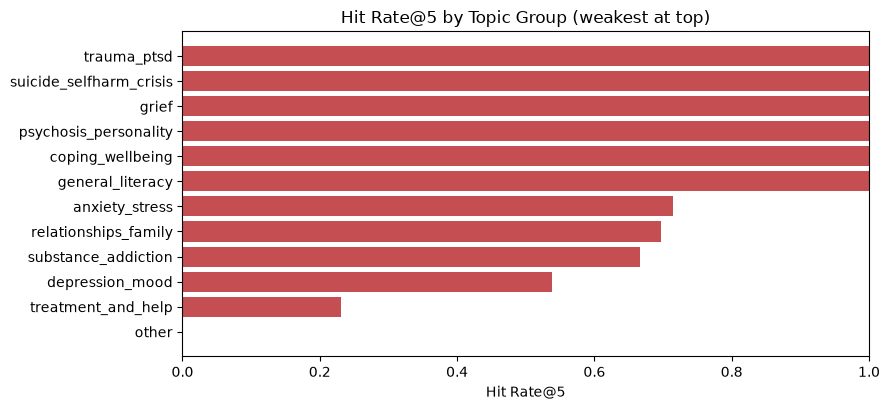

In [17]:
fig, ax = plt.subplots(figsize=(9, max(3, 0.35 * len(strat_topic))))
ax.barh(strat_topic.index.astype(str), strat_topic["hit_rate"], color="#C44E52")
ax.set_xlabel(f"Hit Rate@{STRAT_K}")
ax.set_xlim(0, 1)
ax.set_title(f"Hit Rate@{STRAT_K} by Topic Group (weakest at top)")
plt.tight_layout()
plt.show()


If the `safety_sensitive` row scores meaningfully lower than the non-flagged row, or specific topic groups sit far below the rest, that's a priority list for where an advanced retriever (or manual curation of that slice of the corpus) should focus first — not just "improve retrieval in general.

## 10. Summary & Next Steps

This notebook gives you a repeatable baseline for the current cosine-similarity retriever: Hit Rate, MRR, Precision/Recall, NDCG at several values of k, plus latency and a set of concrete failure cases to inspect.

**How to use this going forward:**

1. Keep this notebook (or the `eval_set`, metric functions, and `retrieve_for_eval` in a reusable module) as your evaluation harness.
2. When you try an advanced retriever technique — hybrid search (dense + BM25), a reranker (cross-encoder), query expansion/rewriting, MMR for diversity, or a different embedding model — swap out `retrieve_for_eval` to call the new retriever, and re-run Sections 5–8 unchanged.
3. Compare the new summary table against this one. An improvement is only real if it moves these numbers, not just intuition.
4. Pay particular attention to the **Hit Rate@1 vs Hit Rate@10 gap** from Section 6: a big gap means the right document is usually *found* but not *ranked first* — that's a strong signal a reranker will help more than switching embedding models.
5. Check Section 9 every time you change the retriever: an overall improvement that doesn't also improve (or at least hold steady on) the `safety_sensitive` slice is not a safe tradeoff for this corpus.
6. Periodically re-expand the golden set in Section 2 with hand-labeled multi-relevant-document queries; the corpus-derived set is a good start but a cheap proxy.
